# CS325 Group Project - Credit Card Fraud Detection

## Task:
Detect fraudulent transactions from 284k credit card records — only 0.17% are fraud.

## The most important lesson in ML evaluation:
Accuracy is meaningless on imbalanced data.

## Interesting Aspects:
Extreme class imbalance; need to try different metrics, not just accuracy.

## Dataset:
Kaggle - Credit Card Fraud Detection - https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

## Dataset Summary:
The dataset contains 284,807 transactions that occured over two days in September 2013. Features V1 - V28 are the principal components obtained with PCA to protect user privacy. The only features not transformed are Time (seconds elapsed between the first and current transaction) and Amount. The Class column is the response variable, where 1 represents fraud and 0 represents a legitimate transaction.

## The Imbalance Challenge:
Since only 0.17% of the transactions are fraudulent, if a model simply predicts "Not Fraudulent" on every case, it will achieve a 99.82% accuracy, but fail to catch any actual fraudulent transactions. This makes standard accuracy a deceptive and useless metric for this task.

# Data Preprocessing:

 The Amount feature usually varies significantly in scale compared to the PCA components. It should be scaled to ensure it doesn't disproportionately influence the model.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("creditcard.csv")

# Scale the Amount and Time Features
scaler = StandardScaler()
df['std_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['std_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop the original unscaled columns
df.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# Handling the Imbalance:
To ensure the Random Forest learns the characteristics of the minority class (Fraud), we will use Class Weights to more heavily penalize mistakes on fraud cases.

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets.
# We use 'stratify=y' to ensure both sets have the same percentage of fraud the original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# The 'balanced' mode uses the values of y to automatically adjust weights
# inversely proportional to class frequencies.
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


# Model Evaluation Methodology
In fraud detection, the cost of a False Negative (missing a fraudulent transaction) is significantly higher than the cost of a False Positive (flagging a legitimate transaction for review). Therefore, we prioritize Recall while maintaining a reasonable Precision.

***Precision:*** Of all transactions flagged as fraud, how many are actually fraudulent?

***Recall:*** Of all actual fraudulent cases, how many did we successfully catch?

***F1-Score:*** The harmonic mean of Precision and Recall, providing a single score that balances both.

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962



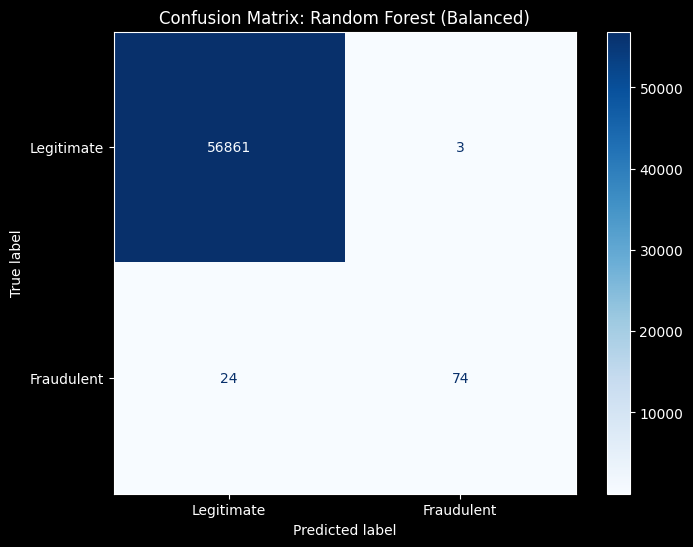

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate Predictions using the Test Set
y_pred = rf_weighted.predict(X_test)

# Print the Classification Report
# This gives us Precision, Recall, and F1-score for both classes
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))

# Create and Plot the Confusion Matrix
# This is a visual representation of TP, TN, FP, FN
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraudulent'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Random Forest (Balanced)')
plt.show()

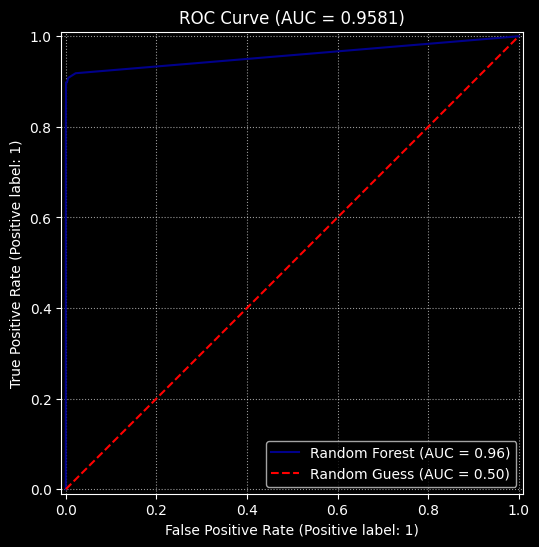

The Area Under the ROC Curve (ROC AUC) is: 0.9581


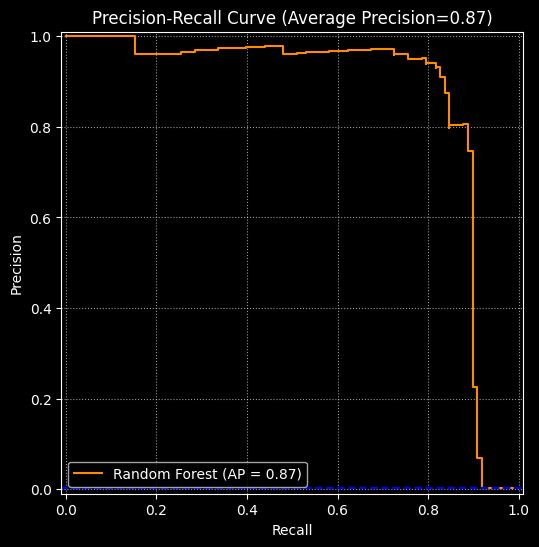

In [36]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay, average_precision_score

# Calculate the Average Precision score and the ROC AUC Score
# We use the probability of the positive class (Fraud)
# This represents the probability that the model will rank a random fraud case higher than random legitimate case
y_score = rf_weighted.predict_proba(X_test)[:, 1]
average_precision = average_precision_score(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

# -- ROC Curve --
# Plot the ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
display = RocCurveDisplay.from_estimator(
    rf_weighted, X_test, y_test, name="Random Forest", ax=ax, curve_kwargs={"color": "darkblue"}
)

# Add a "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC = 0.50)')
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print(f"The Area Under the ROC Curve (ROC AUC) is: {roc_auc:.4f}")

# -- Precision/Recall Curve --
# Plot the Precision-Recall Curve
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(
    rf_weighted, X_test, y_test, name="Random Forest", ax=ax, color="darkorange"
)
plt.xlabel('Recall')
plt.ylabel('Precision')

# Add a baseline line
# The baseline for a PR curve is the ratio of positive instances (Fraud / Total)
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='blue', linestyle='--', label=f'Baseline ({baseline:.4f})')

plt.title(f'Precision-Recall Curve (Average Precision={average_precision:.2f})')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

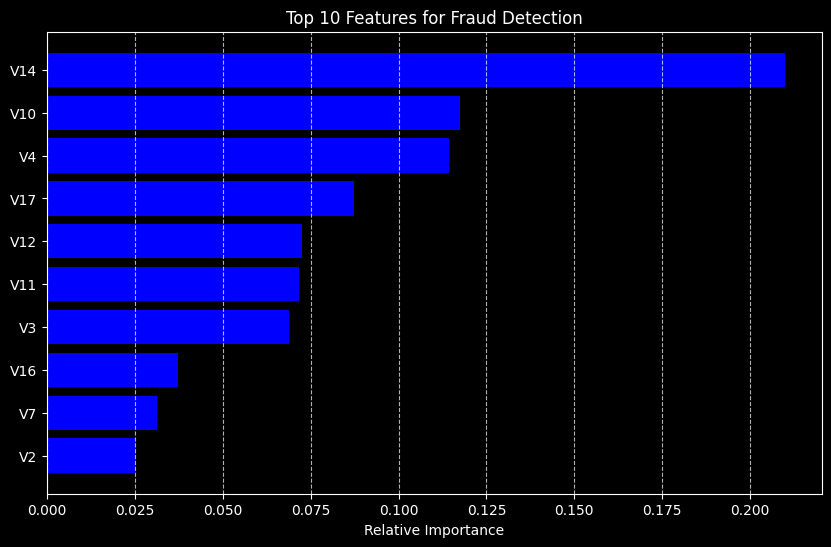

In [37]:
# Get feature importances from the trained model
importances = rf_weighted.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]  # Get the top 10 most important features

# Plot the results
plt.figure(figsize=(10, 6))
plt.title('Top 10 Features for Fraud Detection')
plt.barh(range(len(indices)), importances[indices], color='Blue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()